In [1]:
import os
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import re
import matplotlib.cm as cm
import matplotlib as mlp
import inspect
from matplotlib.lines import Line2D
from matplotlib import colors
import matplotlib.patches as patches
# plt.style.use('tableau-colorblind10')
# plt.rcParams['font.size'] = 16
# print(inspect.getsource(plot_boxes))

In [2]:
def get_dataset(data_dir):
    task_items = []
    servers_hist_all = []
    nodes = []
    net_measures = []

    task_items = pd.read_csv('{}/tasks.gz'.format(data_dir)).to_dict('records')
    servers_hist_all = pd.read_csv('{}/servers.gz'.format(data_dir)).to_dict('records')
    nodes = pd.read_csv('{}/nodes.gz'.format(data_dir)).to_dict('records')
    conn_hist = pd.read_csv('{}/nodes.gz'.format(data_dir)).to_dict('records')
    # net_measures = pd.read_csv('{}/net_measures.gz'.format(data_dir)).to_dict('records')

    # servers_hist_mec_on = db.get_items_in_collection(collection='servers_hist', query={'mec': True}, sort=('time', 1))
    servers_hist_mec_on = [t for t in servers_hist_all if t['mec']]
    # servers_hist_control = db.get_items_in_collection(collection='servers_hist', query={'control_loop': True}, sort=('time', 1))
    servers_hist_control = [t for t in servers_hist_all if t['control_loop']]
    nodes_map = {n['ip']: n['name'] for n in nodes}
    reference_time = task_items[0]['send_time']

    return [task_items, servers_hist_all, nodes, servers_hist_mec_on, servers_hist_control, nodes_map, reference_time]

def process_dataset(target_dir, user=True):
    data = get_dataset(target_dir)

    done_tasks = [t for t in data[0] if t['status']== 'Done'  and isinstance(t['npath'], str) and t['computation_time'] <= 2.5]
    fail_tasks = [t for t in data[0] if t['status']== 'Fail' or not isinstance(t['npath'], str) or t['computation_time'] > 2.5]
    print(f'Success rate {len(done_tasks)/(len(done_tasks)+len(fail_tasks))}, Total Tasks: {len(done_tasks)+len(fail_tasks)}')
    nodes = data[2]
    user_nodes = [n for n in nodes if 'gn' in n['name']]
    sat_nodes = [n for n in nodes if 'st' in n['name']]
    gateway_nodes = [n for n in nodes if 'gg' in n['name']]

    geo_distances = []

    for ggn in gateway_nodes:
        for un in user_nodes:
            geo_dis = calculate_geo_distance([un['latitude'], un['longitude']],[ggn['latitude'], ggn['longitude']])
            geo_distances.append([ggn['name'], un['name'], geo_dis])
    
    if geo_distances:
        geo_distances = pd.DataFrame(data=geo_distances, columns=['gateway', 'users', 'distances']).sort_values('distances')
        # offset = 0
        

    network_data = []
    if user:
        for un in user_nodes:
            # print(f'user is {un["name"]}')
            # if ( un["name"]=='gn207'):
            #     continue
            user_tasks = [t for t in done_tasks if un['name'] == (eval(t['npath']))[0]]
            # print(f"Tasks for user {un['name']} id {un['id']} are {len(user_tasks)}")
            latency = [t['computation_time'] for t in user_tasks]
            net_hops = [len(eval(t['npath'])) for t in user_tasks]
            # if f"gn{un['id']+offset}" == 'gn202':
            #     print( eval(user_tasks[0]['npath']) )
            latency_ms = (np.array(latency)*1000.0 - 250) / 2.0
            npaths = [eval(t['npath']) for t in user_tasks]
            times = [t['time'] for t in user_tasks]
            network_data.append([un['name'], np.mean(latency_ms), np.mean(net_hops), np.max(latency_ms), np.min(latency_ms), np.std(latency_ms), 
                                 latency_ms, npaths, times, len(user_tasks), user_tasks])
    else:
        latency = [t['computation_time'] for t in done_tasks]
        net_hops = [len(eval(t['npath'])) for t in done_tasks]
        # if f"gn{un['id']+offset}" == 'gn202':
        #     print( eval(user_tasks[0]['npath']) )
        latency_ms = (np.array(latency)*1000.0 -250) / 2.0 # RTT
        npaths = [eval(t['npath']) for t in done_tasks]
        times = [t['time'] for t in done_tasks]
        network_data.append([target_dir, np.mean(latency_ms), np.mean(net_hops), np.max(latency_ms), np.min(latency_ms), np.std(latency_ms), 
                             latency_ms, npaths, times, len(done_tasks), done_tasks])

    network_data = pd.DataFrame(data=network_data, columns=['users', 'latency', 'hops', 'max', 'min', 'std', 
                                                            'data', 'paths', 'times', 'ntasks', 'tasks'])

    return [network_data, geo_distances]

def calculate_geo_distance(lat_lon1, lat_lon2):
    R = 6373.0
    lat1 = math.radians(lat_lon1[0])
    lon1 = math.radians(lat_lon1[1])
    lat2 = math.radians(lat_lon2[0])
    lon2 = math.radians(lat_lon2[1])


    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = math.sin(dlat / 2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    distance = R * c
    return distance

def process_distribution_dir(distribution_dir, label, user=True):
    dataset_dirs = os.listdir(distribution_dir)
    
    data_dict = {}
    for i, d_dir in enumerate(dataset_dirs):
        g_servers = int(re.search("_(\\d+)ggs_", d_dir).group(1))
        s_servers = int(re.search("_(\\d+)sts_", d_dir).group(1))
        # print(g_servers)
        data = process_dataset(f'{distribution_dir}/{d_dir}', user)
        data_label = label
        if s_servers > 0:
            data_label += f', SS:{s_servers:02d}'
        if g_servers > 0:
            data_label += f', GS:{g_servers:02d}'
        print(data_label)
        data_dict.update({data_label: data})
    return data_dict
    
def get_data_dict(base_dir, data_groups=None):
    terrestrial_dir = f'{base_dir}/terrestrial'
    along_dir = f'{base_dir}/along-orbit'
    cross_dir = f'{base_dir}/cross-plane'
    ssingle_dir = f'{base_dir}/space-single'
    farthest_dir = f'{base_dir}/farthest-choice'
    hybrid_dir = f'{base_dir}/hybrid'
    data_dict = {}
    if not data_groups:
        data_dict.update(process_distribution_dir(terrestrial_dir, 'Terrestrial'))
        geo_distances = data_dict['Terrestrial, GS:01'][1]
        data_dict.update(process_distribution_dir(ssingle_dir, 'Space: Single'))
        data_dict.update(process_distribution_dir(cross_dir, 'Space: Cross Plane'))
        data_dict.update(process_distribution_dir(along_dir, 'Space: Along Orbit'))
        data_dict.update(process_distribution_dir(farthest_dir, 'Space: Farthest Choice'))
    else:
        data_dict.update(process_distribution_dir(terrestrial_dir, 'Terrestrial'))
        geo_distances = data_dict['Terrestrial, GS:01'][1]
        if 'farthest-choice' in data_groups:
            data_dict.update(process_distribution_dir(farthest_dir, 'Space: Farthest Choice'))
        if 'hybrid' in data_groups:
            data_dict.update(process_distribution_dir(hybrid_dir, 'Hybrid'))
        if 'cross-plane' in data_groups:
            data_dict.update(process_distribution_dir(cross_dir, 'Space: Cross Plane'))
        if 'along-orbit' in data_groups:
            data_dict.update(process_distribution_dir(along_dir, 'Space: Along Orbit'))
            
        
        

    # data_dict.update(process_distribution_dir(hybrid_dir, 'Hybrid'))
    
    for data_key in data_dict:
        df_data = pd.merge(geo_distances, data_dict[data_key][0], on='users')
        data_dict[data_key] = df_data
    return data_dict

In [3]:
def plot_constellation_values(data_dict, stat='latency', init_index=0, end_index=None):
    # cmapb = mlp.colormaps['winter'].resampled(3)
    # cmapr = mlp.colormaps['autumn'].resampled(7)
    # cmapg = mlp.colormaps['summer'].resampled(5)
    # cmapp = mlp.colormaps['spring'].resampled(2)
    lwidth= 1

    d_keys = data_dict.keys()
    shade_init = 0.1
    shade_end = 1.0
    t_keys = [k for k in d_keys if 'Terrestrial' in k]
    t_keys.sort(reverse=True)
    # cmapb = cm.Blues(np.linspace(shade_init, shade_end, len(t_keys)+2))
    cmapdiv = cm.coolwarm(np.linspace(shade_init, shade_end, len(t_keys)))

    s_keys = [k for k in d_keys if 'Terrestrial' not in k and 'Farthest' not in k and 'Hybrid' not in k]
    s_keys.sort(reverse=False)
    # cmapr = cm.Reds(np.linspace(shade_init, shade_end, len(s_keys)+2))  

    f_keys = [k for k in d_keys if 'Farthest'  in k]
    f_keys.sort(reverse=True)
    # cmapg = cm.Greens(np.linspace(shade_init, shade_end, len(f_keys)+2))

    h_keys = [k for k in d_keys if 'Hybrid'  in k]
    h_keys.sort(reverse=False)
    # cmapp = cm.RdPu(np.linspace(shade_init, shade_end, len(h_keys)+2))

    def plot_group_filter(group_keys, cmap, stat, init_index=0, end_index=None):
        for i_col, d_key in enumerate(group_keys):
            data_df = data_dict[d_key]
            data_df.sort_values('distances')
            end_index = data_df.shape[0] if not end_index  else end_index
            distances, latency = data_df['distances'][:end_index], data_df[stat][init_index:end_index]
            ax.plot(distances, latency, label=d_key, linewidth=lwidth, marker='x', linestyle='--', ms=5, color=cmap[i_col+2])
            
    
    fig, ax = plt.subplots(figsize=(16,5))
    
    plot_group_filter(t_keys, cmapdiv, stat, init_index, end_index)
    plot_group_filter(s_keys, cmapdiv, stat, init_index, end_index)
    plot_group_filter(f_keys, cmapdiv, stat, init_index, end_index)
    plot_group_filter(h_keys, cmapdiv, stat, init_index, end_index)
    
    # ax.set_ylabel("$\overline{\lambda}_{\\tau}$ [ms]")
    ax.set_ylabel(f"{stat} [ms]")
    ax.set_xlabel('Distance [Km]')
    
    # fig.legend(handles=legend_elements, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.01))
    plt.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=3)
    
    plt.grid(linewidth=0.3)

In [18]:
def plot_boxes(data_dict):
    lwidth= 2
    fsize = 24
    matplotlib.rcParams.update({'font.size': fsize})

    # red_colors = cm.Reds(np.linspace(0.3, 0.6, 4))  # 3 shades from the Reds colormap
    # blue_colors = cm.Blues(np.linspace(0.3, 0.6, 6))  # 3 shades from the Blues colormap

    def plot_group_boxes(group_keys, cmap, ax, title=''):
        group_len = len(group_keys)
        l_handlers=[]
        for i_col, d_key in enumerate(group_keys):
            if d_key == "":
                continue
            
            data_df = data_dict[d_key]
            distances, latency = data_df['distances'], data_df['latency']
            data = data_df['data']
            mean_rtt = np.mean(data_df['latency'])
            props = dict(color=cmap[i_col], linewidth=lwidth)
            lprops = dict(linewidth=lwidth)
            ue_len = len(data_df)
            ax.set_title(title)
            ax.boxplot(data, showfliers=False, positions=[(group_len+1)*i+i_col+1 for i in range(ue_len)], 
                       boxprops=props, meanline=False, medianprops=lprops,
                       whis=(0,85), whiskerprops=lprops, capprops=lprops)
            ax.set_xticks([(group_len+1)*i + int(group_len/2)+1 for i in range(ue_len)],
                  labels=[f"u{int(u[2:])-198}" for u in data_df['users']])
            # ax.hlines(mean_rtt, 1, (group_len+1)*ue_len-1, color=cmap[i_col])
            label = re.search(":(\\d\\d)", d_key).group(1)

            # l_handlers.append(Line2D([0], [0], linestyle='-', marker=None, linewidth=lwidth, color=cmap[i_col], label=label,
                        # markerfacecolor=cmap[i_col], markersize=3))
            # ax.set_ylabel("Latency [ms]")
        # ax.legend(handles=l_handlers, loc='center right', bbox_to_anchor=(1.10, 0.5), title='Servers')
        ax.grid()
            # ax.set_xlabel('Distance [Km]')

    d_keys = data_dict.keys()
    shade_init = 0.0
    shade_end = 1.0
    t_keys = [k for k in d_keys if 'Terrestrial' in k]
    t_keys.sort(reverse=False)
    cmap1 = cm.coolwarm(np.linspace(shade_init, shade_end, len(t_keys)))
    n_grps = 1
    
    # s_keys = [k for k in d_keys if 'Terrestrial' not in k and 'Farthest' not in k and 'Hybrid' not in k]
    # if len(s_keys) > 0:
    #     s_keys.sort(reverse=False)
    #     s_keys.insert(0, s_keys.pop())
    #     s_keys = [s_keys[0]] + s_keys[3:] + s_keys[1:3]
    #     cmap2 = cm.coolwarm(np.linspace(shade_init, shade_end, len(s_keys)))
    #     n_grps += 1

    c_keys = [k for k in d_keys if 'Cross' in k]
    if len(c_keys) > 0:
        c_keys.sort(reverse=False)
        c_keys = [''] + c_keys
        n_grps += 1
    a_keys = [k for k in d_keys if 'Along' in k]
    if len(a_keys) > 0:
        a_keys.sort(reverse=False)
        a_keys = [''] + a_keys
        n_grps += 1

    
    f_keys = [k for k in d_keys if 'Farthest'  in k]
    if len(f_keys) > 0:
        f_keys.sort(reverse=False)
        if len(t_keys) > len(f_keys):
            f_keys = f_keys + ['']*(len(t_keys)-len(f_keys))
        cmap3 = cm.coolwarm(np.linspace(shade_init, shade_end, len(f_keys)))
        n_grps += 1

    h_keys = [k for k in d_keys if 'Hybrid' in k]
    if len(h_keys) > 0:
        h_keys.sort(reverse=False)
        h_keys = ['']  + h_keys
        n_grps += 1

    # cmapc = cm.tab20b(len(t_keys)+ len(s_keys) +len(f_keys))

    fig, axs = plt.subplots(nrows=n_grps, sharey=True, sharex=True)
    fig.set_figwidth(13)
    fig.set_figheight(25)
    d_keys = data_dict.keys()
    if n_grps ==1:
        axs = [axs]
    plot_group_boxes(t_keys, cmap1, axs[0], 'Terrestrial')
    axi = 1
    if len(f_keys) > 0:
        plot_group_boxes(f_keys, cmap3, axs[axi], 'Space: FPS')
        axi += 1
    if len(c_keys) > 0:
        plot_group_boxes(c_keys, cmap1, axs[axi], 'Space: CP')
        axi += 1
    if len(a_keys) > 0:
        plot_group_boxes(a_keys, cmap1, axs[axi], 'Space: AO')
        axi += 1


    if len(h_keys) > 0:
        plot_group_boxes(h_keys, cmap1, axs[axi], 'Hybrid')
    
    fig.text(0.01, 0.5, "$R_i$ [ms]", va='center', rotation='vertical')
    fig.tight_layout(pad=0.6, rect= (0.02, 0.03, 0.97, 1))
    

        
    # legend_elements = [Line2D([0], [0], linestyle='-', marker=None, color=plot_colors[color_index[i]], label='{}'.format(orchs_dic[o]),
                        # markerfacecolor=plot_colors[color_index[i]], markersize=10) for i, o in enumerate(orchs_keys)]
    
    # fig.legend(handles=legend_elements, frameon=False)

    servers = [1, 2, 4, 6, 8, 10]

    
    handlers = [(Line2D([0], [0], linestyle='-', marker=None, linewidth=lwidth, color=cmap1[i], label=str(s),
                markerfacecolor=cmap1[i], markersize=3)) for i, s in enumerate(servers)]

    plt.legend(handles=handlers,ncols=6, loc='lower center', bbox_to_anchor=(0.5, -0.45), title='$K$')
    
    
    # plt.set_ylabel("Latency [ms]")
    plt.savefig('rtt_boxes.pdf', bbox_inches='tight')



In [5]:

# base_dir = 'data/sims/space_clouds_24_04_25'

#Gateway delay 50 ms
# base_dir = 'data/sims/space_clouds_30_04_25'

# Gateway delay 30 ms
# base_dir = 'data/sims/space_clouds_02_05_25'

#Gateway delay 15 ms
# base_dir = 'data/sims/space_clouds_03_05_25'

# base_dir = 'data/sims/space_clouds_30_05_25'
# data_dict = get_data_dict(base_dir, ['farthest-choice', 'cross-plane', 'along-orbit', 'hybrid'])

base_dir = 'data/sims/space_clouds_05_06_25'
data_dict = get_data_dict(base_dir,  ['farthest-choice', 'cross-plane', 'along-orbit', 'hybrid'])

d_keys = data_dict.keys()
t_keys = [k for k in d_keys if 'Terrestrial' in k]
t_keys.sort(reverse=False)
n_grps=1

c_keys = [k for k in d_keys if 'Cross' in k]
if len(c_keys) > 0:
    c_keys.sort(reverse=False)
    c_keys = [''] + c_keys
    n_grps += 1

a_keys = [k for k in d_keys if 'Along' in k]
if len(a_keys) > 0:
    a_keys.sort(reverse=False)
    a_keys = [''] + a_keys
    n_grps += 1
print(a_keys)


f_keys = [k for k in d_keys if 'Farthest'  in k]
if len(f_keys) > 0:
    f_keys.sort(reverse=False)
    # if len(t_keys) > len(f_keys):
    #     f_keys = f_keys + ['']*(len(t_keys)-len(f_keys))
    n_grps += 1

h_keys = [k for k in d_keys if 'Hybrid' in k]
if len(h_keys) > 0:
    h_keys.sort(reverse=False)
    h_keys = ['']  +h_keys
    n_grps += 1



Success rate 0.9648178197374244, Total Tasks: 13558
Terrestrial, GS:08
Success rate 0.968017541206714, Total Tasks: 13226
Terrestrial, GS:10
Success rate 0.974665780338282, Total Tasks: 13539
Terrestrial, GS:04
Success rate 0.9705093833780161, Total Tasks: 7833
Terrestrial, GS:01
Success rate 0.9716393820613327, Total Tasks: 13011
Terrestrial, GS:06
Success rate 0.9764775501146534, Total Tasks: 13519
Terrestrial, GS:02
Success rate 0.9828400102066854, Total Tasks: 15676
Space: Farthest Choice, SS:08
Success rate 0.9821918682581222, Total Tasks: 15667
Space: Farthest Choice, SS:04
Success rate 0.9819411652096228, Total Tasks: 15671
Space: Farthest Choice, SS:02
Success rate 0.9818785094435937, Total Tasks: 15672
Space: Farthest Choice, SS:06
Success rate 0.9815005801211809, Total Tasks: 15514
Space: Farthest Choice, SS:01
Success rate 0.982129180495277, Total Tasks: 15668
Space: Farthest Choice, SS:10
Success rate 0.9802519577800477, Total Tasks: 14685
Hybrid, SS:01, GS:01
Success rate 

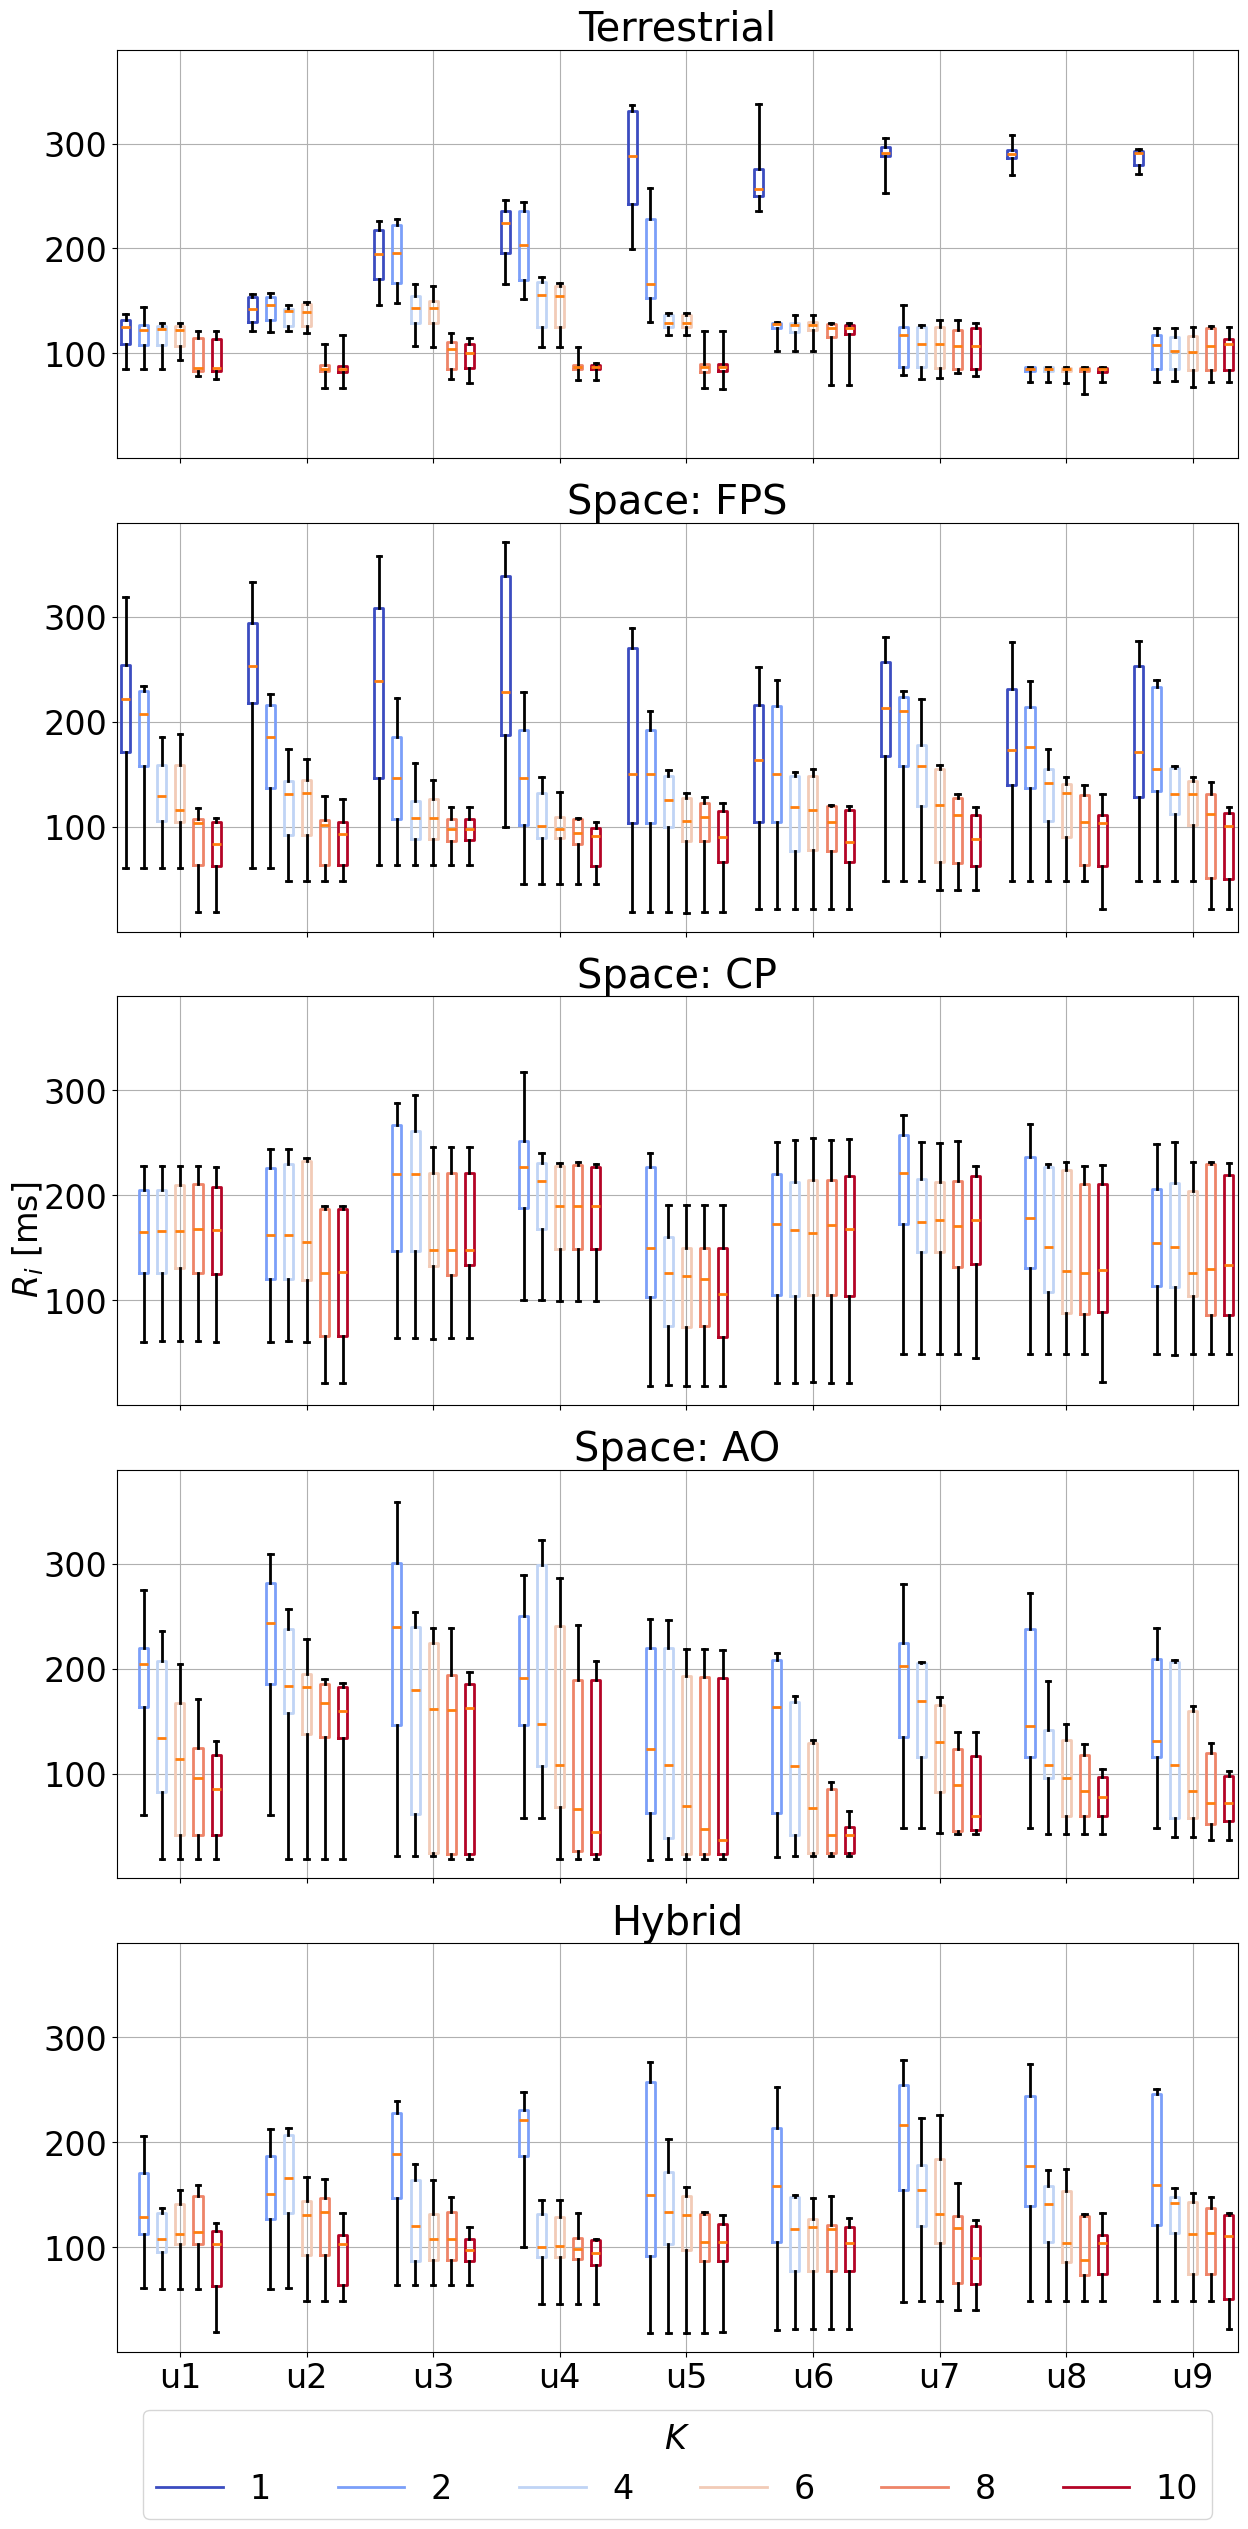

In [19]:
plot_boxes(data_dict)

[1, 2, 4, 6, 8, 10]
[np.float64(212.8737181213397), np.float64(142.02541646140335), np.float64(124.06270173001413), np.float64(124.96995088552829), np.float64(102.40614981053847), np.float64(102.78127237771494)]
[np.float64(41.332075240608894), np.float64(30.13117852602465), np.float64(22.62184549124585), np.float64(24.367572850431426), np.float64(24.718801934377208), np.float64(25.39969065912543)]
[1, 2, 4, 6, 8, 10]
[np.float64(181.3567352781459), np.float64(168.99468113339668), np.float64(160.77331363154815), np.float64(155.37984825175693), np.float64(153.31460193351464)]
[np.float64(40.23581454290304), np.float64(36.64738271644157), np.float64(35.49021682078229), np.float64(35.91756279272834), np.float64(36.44739932641512)]
[1, 2, 4, 6, 8, 10]
[np.float64(183.30403274749534), np.float64(146.73986617817525), np.float64(119.63734023287667), np.float64(101.04267356385864), np.float64(92.07273710383002)]
[np.float64(46.57458975560848), np.float64(42.92677876450369), np.float64(39.89256

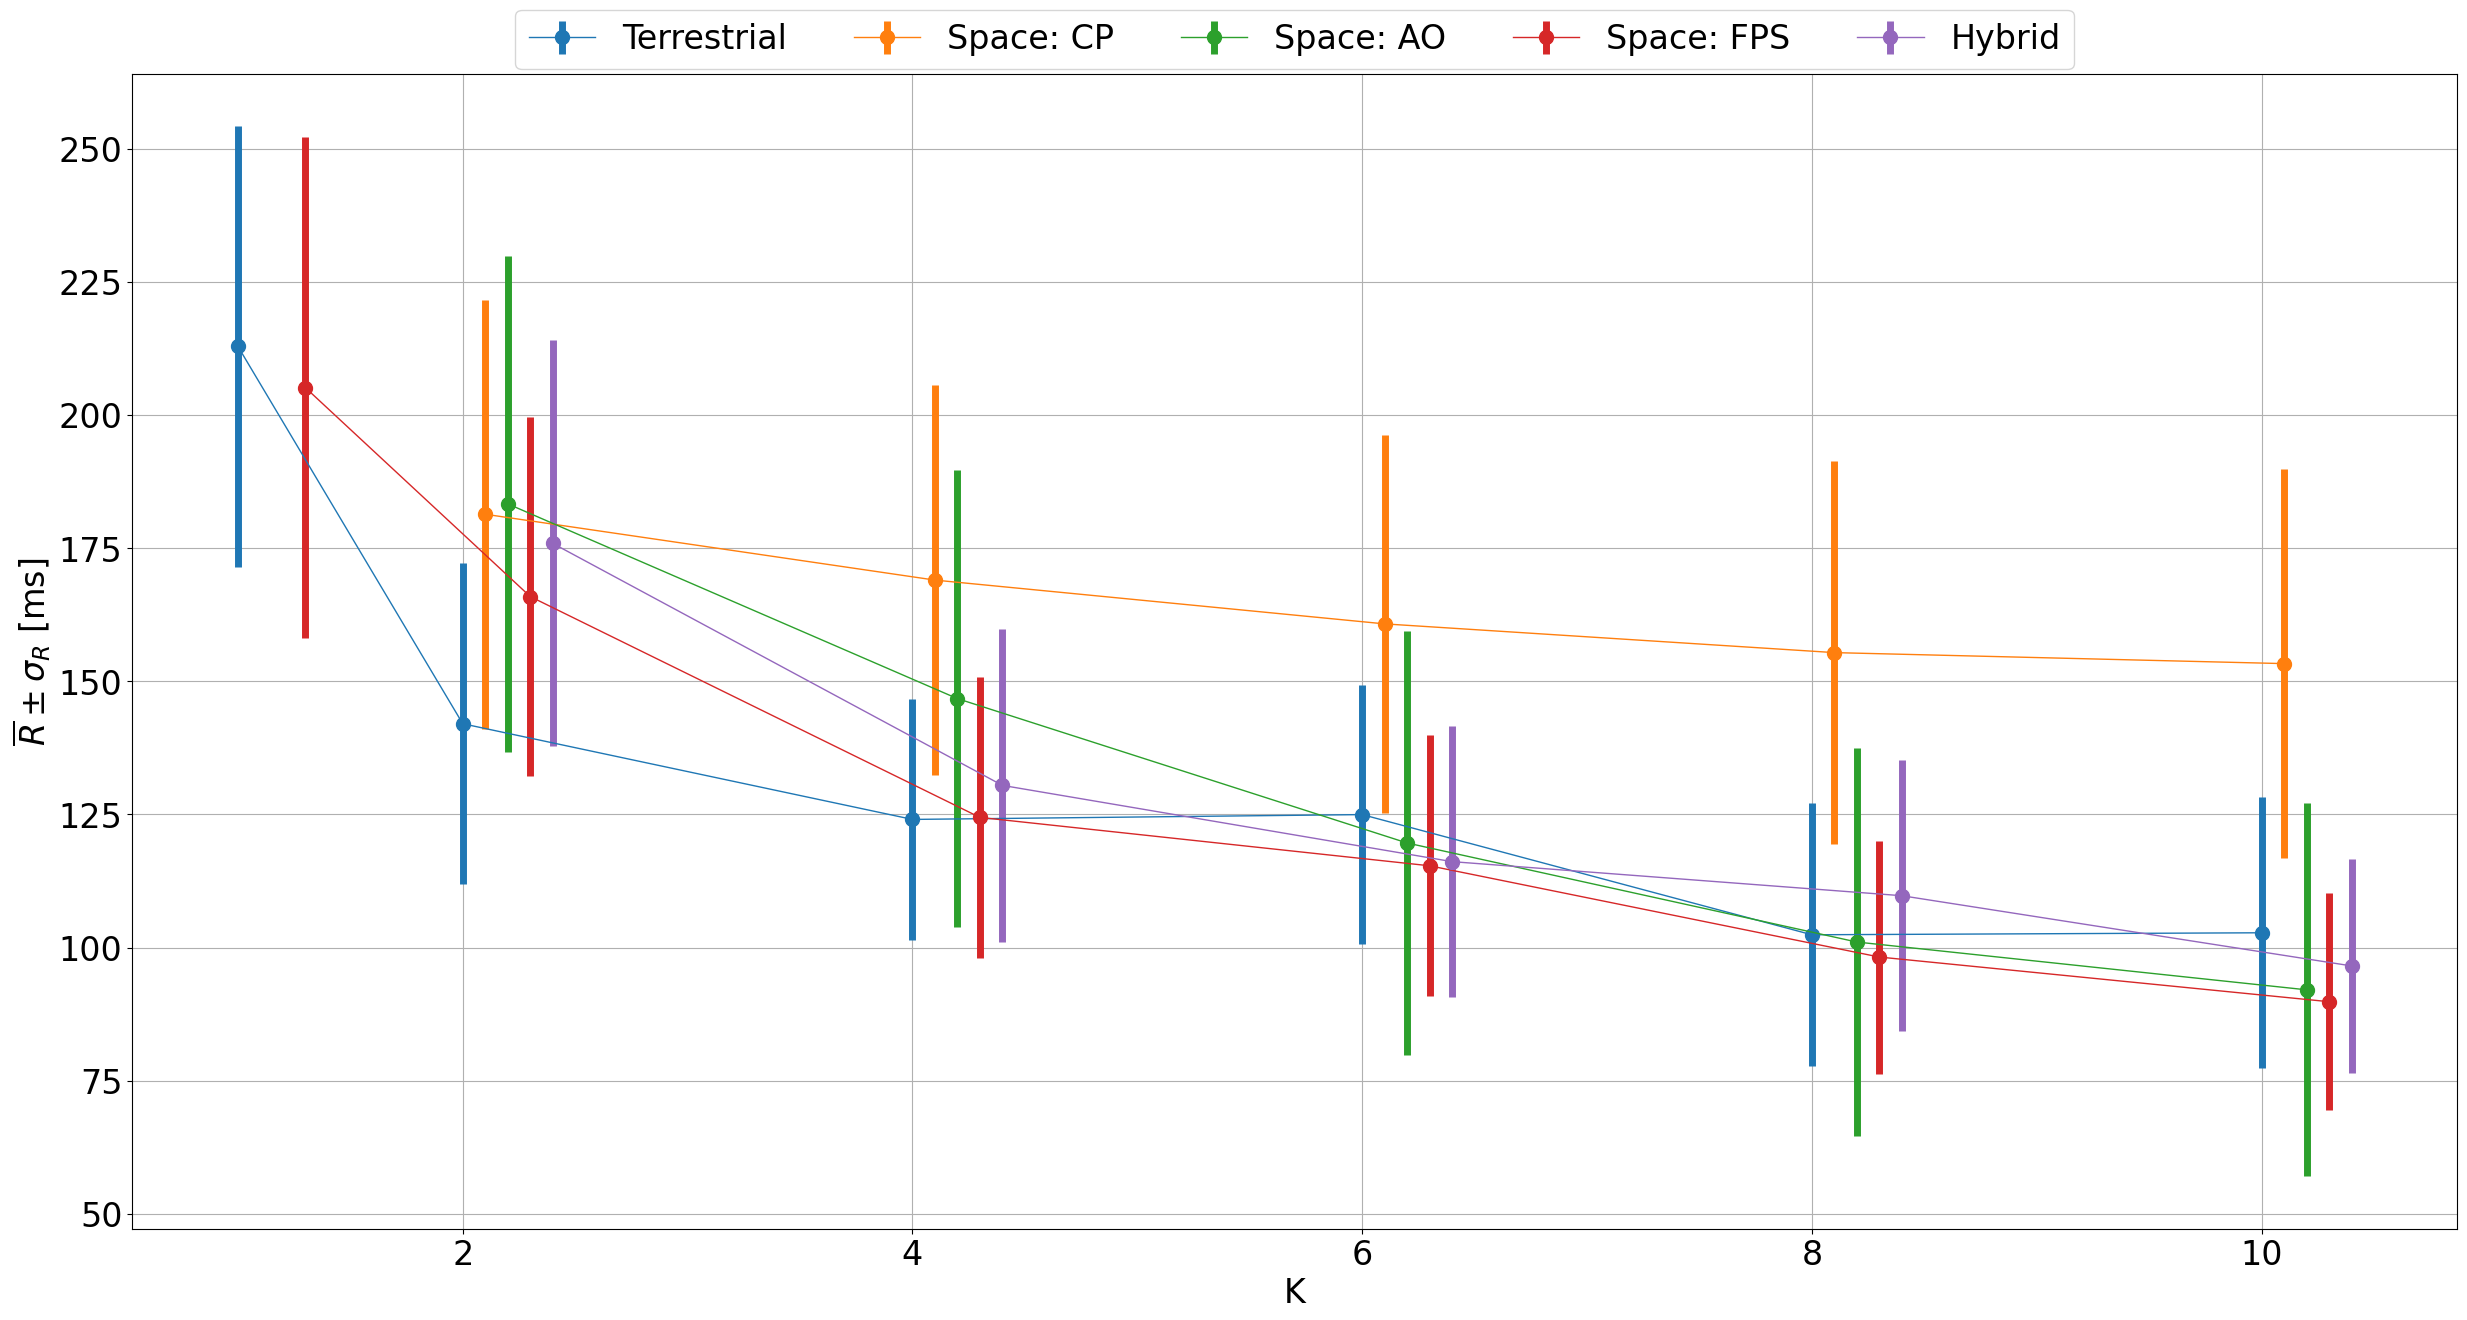

In [8]:
def plot_errors(keys, label, index, ax):

     # = [int(re.search(":(\\d\\d)", d_key).group(1))+index*0.1 for d_key in keys]

    means = [np.mean(np.concat(data_dict[d_key]['data'])) for d_key in keys if d_key]
    errors = [np.std(np.concat(data_dict[d_key]['data']))/2 for d_key in keys if d_key]
    mservers = [s+index*0.1 for s, k in zip(servers, keys) if k ]

    ax.errorbar(mservers, means, yerr=errors, fmt='-o',linewidth=1, elinewidth=5, label=label, markersize=10)
    print(servers)
    print(means)
    print(errors)

d_keys = data_dict.keys()
# t_keys = [k for k in d_keys if 'Terrestrial' in k]
# t_keys.sort(reverse=False)
n_grps = 1


# f_keys = [k for k in d_keys if 'Farthest'  in k]
if len(f_keys) > 0:
    n_grps += 1
    # f_keys.sort(reverse=False)
    # if len(t_keys) > len(f_keys):
    #     f_keys = f_keys + ['']*(len(t_keys)-len(f_keys))

if len(h_keys) > 0:
    n_grps += 1

fsize = 24
matplotlib.rcParams.update({'font.size': fsize})

fig, ax = plt.subplots(nrows=1, ncols=1)
fig.set_figwidth(30)
fig.set_figheight(15)
servers = [1, 2, 4, 6, 8 ,10]
plot_errors(t_keys, 'Terrestrial', 0, ax)
plot_errors(c_keys, 'Space: CP', 1, ax)
plot_errors(a_keys, 'Space: AO', 2, ax)
plot_errors(f_keys, 'Space: FPS', 3, ax)
plot_errors(h_keys, 'Hybrid', 4, ax)


# tks = [s+(n_grps-1)/2 for s in servers]

# plt.xticks(servers, labels=['1', '3', '5', '7', '10'])
plt.xlabel('K')
plt.ylabel('$ \\overline{R} \\pm \\sigma_R$ [ms]')
plt.grid()
plt.legend(ncols=5, loc='upper center', bbox_to_anchor=(0.5, 1.07))
plt.savefig('rtt_means.pdf', bbox_inches = 'tight')
# plt.save


In [9]:

def mean_errors(keys, label):

     # = [int(re.search(":(\\d\\d)", d_key).group(1))+index*0.1 for d_key in keys]

    means = [np.mean(np.concat(data_dict[d_key]['data'])) for d_key in keys if d_key]
    errors = [np.std(np.concat(data_dict[d_key]['data'])) for d_key in keys if d_key]
    return means, errors

d_keys = data_dict.keys()
n_grps = 1

if len(f_keys) > 0:
    n_grps += 1

if len(h_keys) > 0:
    n_grps += 1

servers = [1, 2, 4, 6, 8 ,10]
labels = ['Terrestrial', 'Space: FPS', 'Space: AO', 'Space: CP', 'Hybrid']
keys  = [t_keys, f_keys, a_keys, c_keys, h_keys]

df = pd.DataFrame()

for label, key in zip(labels, keys):
    m, e = mean_errors(key, label)
    if len(m) == 5:
        m = ['-'] + m
        e = ['-'] + e
    df[f'{label} mean'] = m
    df[f'{label} std'] = e

df.to_csv('mean_error.csv')


# mean_errors(c_keys, 'Space: CP')
# plot_errors(a_keys, 'Space: AO', 2, ax)
# plot_errors(f_keys, 'Space: FPS', 3, ax)
# plot_errors(h_keys, 'Hybrid', 4, ax)

In [8]:
print(t_keys[1])
print(data_dict[t_keys[1]]['tasks'][0][0])
data_dict[t_keys[1]]['data'][0][0]

Terrestrial, GS:02
{'_id': '10.0.0.199_dev6_0', 'app': 'App.E_HEALTH', 'computation_time': 0.5099954605102539, 'container_size': 13000, 'dev': 'dev6', 'id': 0, 'ip': '10.0.0.199', 'length': 200000, 'npath': "['gn199', 'st147', 'st146', 'gg208']", 'path': "['10.0.0.199', '10.0.0.208', '10.0.0.199']", 'send_time': 1748989133.7076883, 'server': '10.0.0.208', 'status': 'Done', 'time': 13.764954092645224}


np.float64(129.99773025512695)

Success rate 0.9769706446797924, Total Tasks: 14069
hybrid choice, SS:05, GS:03
Success rate 0.977709761128485, Total Tasks: 15029
hybrid choice, SS:08, GS:02
Success rate 0.9763808139534884, Total Tasks: 13760
hybrid choice, SS:04, GS:04
Success rate 0.9741086587436333, Total Tasks: 14136
hybrid choice, SS:06, GS:04
Success rate 0.9770522658172868, Total Tasks: 13814
hybrid choice, SS:01, GS:03
Success rate 0.9782115609320228, Total Tasks: 14549
hybrid choice, SS:02, GS:02
Success rate 0.979214624238321, Total Tasks: 14770
hybrid choice, SS:05, GS:01
Success rate 0.9752465147908874, Total Tasks: 14705
hybrid choice, SS:07, GS:03
Success rate 0.9761286974571873, Total Tasks: 13489
hybrid choice, SS:03, GS:03
Success rate 0.9769033953391881, Total Tasks: 14461
hybrid choice, SS:06, GS:02
Success rate 0.9795283214606819, Total Tasks: 14459
hybrid choice, SS:03, GS:01
Success rate 0.9786681636376394, Total Tasks: 14251
hybrid choice, SS:04, GS:02


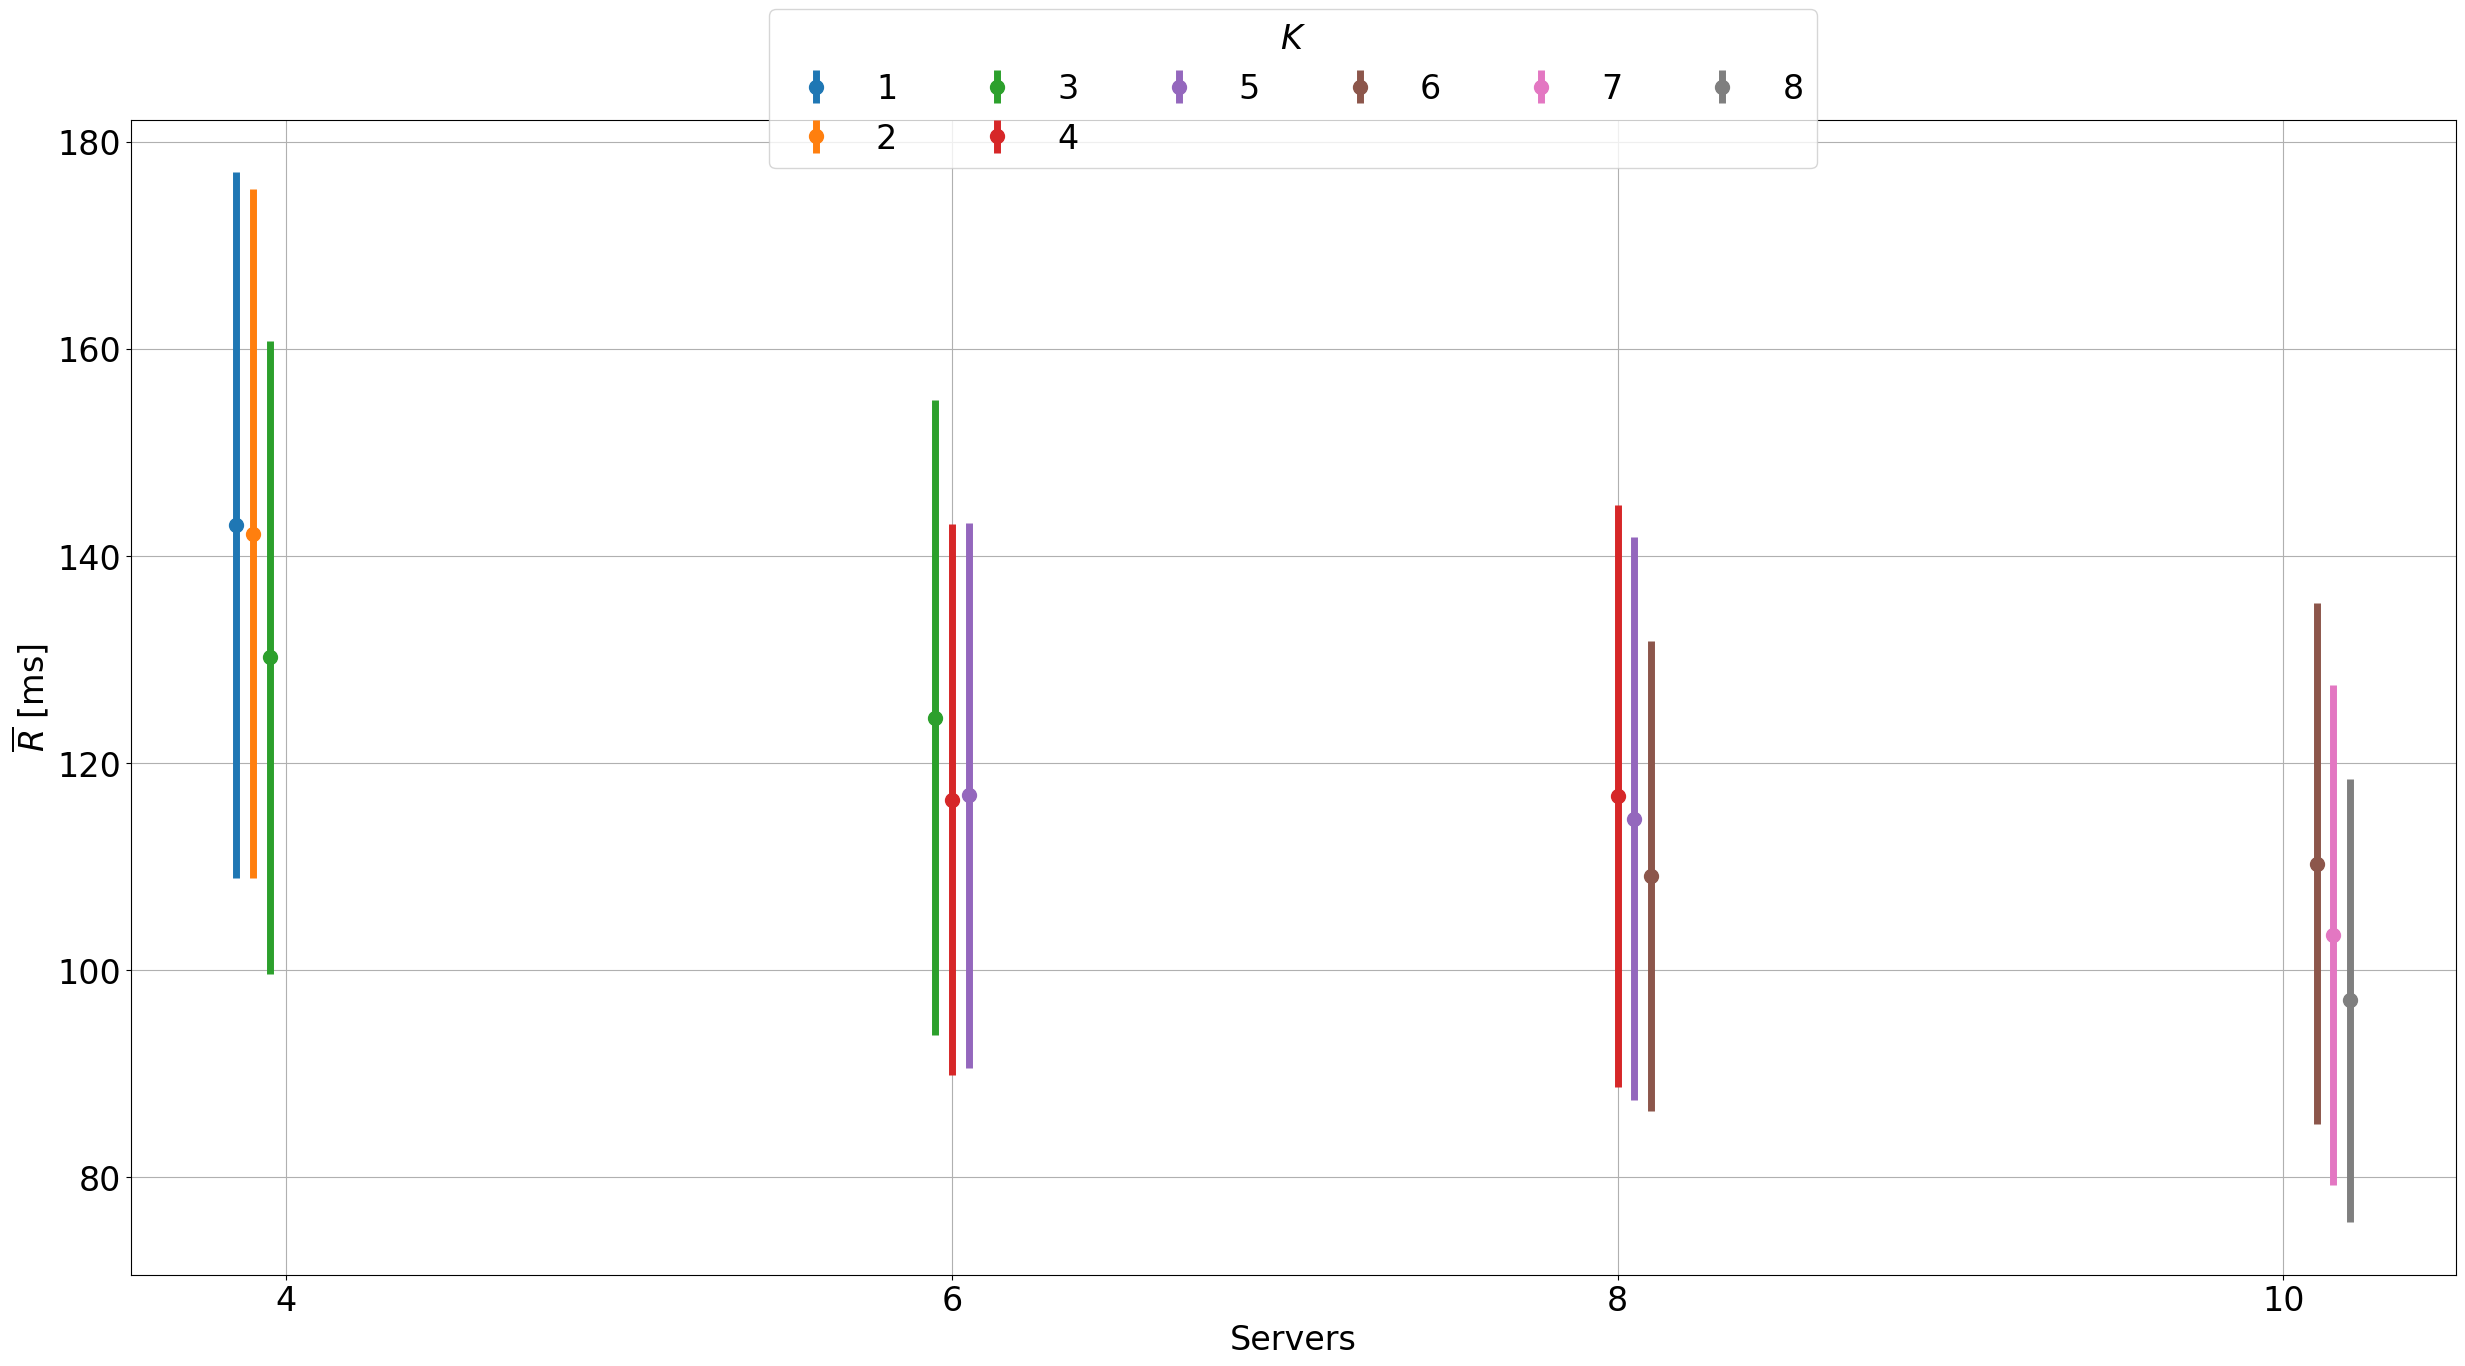

In [10]:
hybrid_dir = 'data/sims/best-hybrid2'
hybrid_dict = process_distribution_dir(hybrid_dir, 'hybrid choice', False)

servers = []
means = []
errors = []
labels = []
for k in hybrid_dict.keys():
    means.append(hybrid_dict[k][0]['latency'].iloc[0])
    errors.append(hybrid_dict[k][0]['std'].iloc[0]/2)
    g_servers = int(re.search("GS:(\\d+)", k).group(1))
    s_servers = int(re.search("SS:(\\d+)", k).group(1))
    servers.append(g_servers+s_servers)
    labels.append(str(s_servers))

# list(means)
# hybrid_dict
# hybrid_dict.keys()

fsize = 24
matplotlib.rcParams.update({'font.size': fsize})
fig, ax = plt.subplots(nrows=1, ncols=1)
fig.set_figwidth(30)
fig.set_figheight(15)

unique_labels = np.unique(labels)
unique_labels.sort()

for index, label in enumerate(unique_labels):
    means_l = [m for m, l in zip(means, labels) if l==label]
    servers_l= [s+index*0.05 for s, l in zip(servers, labels) if l==label]
    # mservers = [s+index*0.1 for s, k in zip(servers, keys) if k ]
    errors_l= [e for e, l in zip(errors, labels) if l==label]
    ax.errorbar(servers_l, means_l, yerr=errors_l, label=label, fmt='-o',linewidth=0, elinewidth=5, markersize=10)

servers_ticks = np.array(range(4, 12, 2))
servers_labels = [str(v) for v in servers_ticks]
servers_ticks = servers_ticks+0.15
plt.xticks(servers_ticks, labels=servers_labels)
plt.xlabel('Servers')
plt.ylabel('$ \\overline{R}$ [ms]')

plt.legend(ncols=6, loc='upper center', bbox_to_anchor=(0.5, 1.11), title='$K$')
plt.grid()

['Space: Farthest Choice, SS:01', 'Space: Farthest Choice, SS:02', 'Space: Farthest Choice, SS:04', 'Space: Farthest Choice, SS:06', 'Space: Farthest Choice, SS:08', 'Space: Farthest Choice, SS:10']


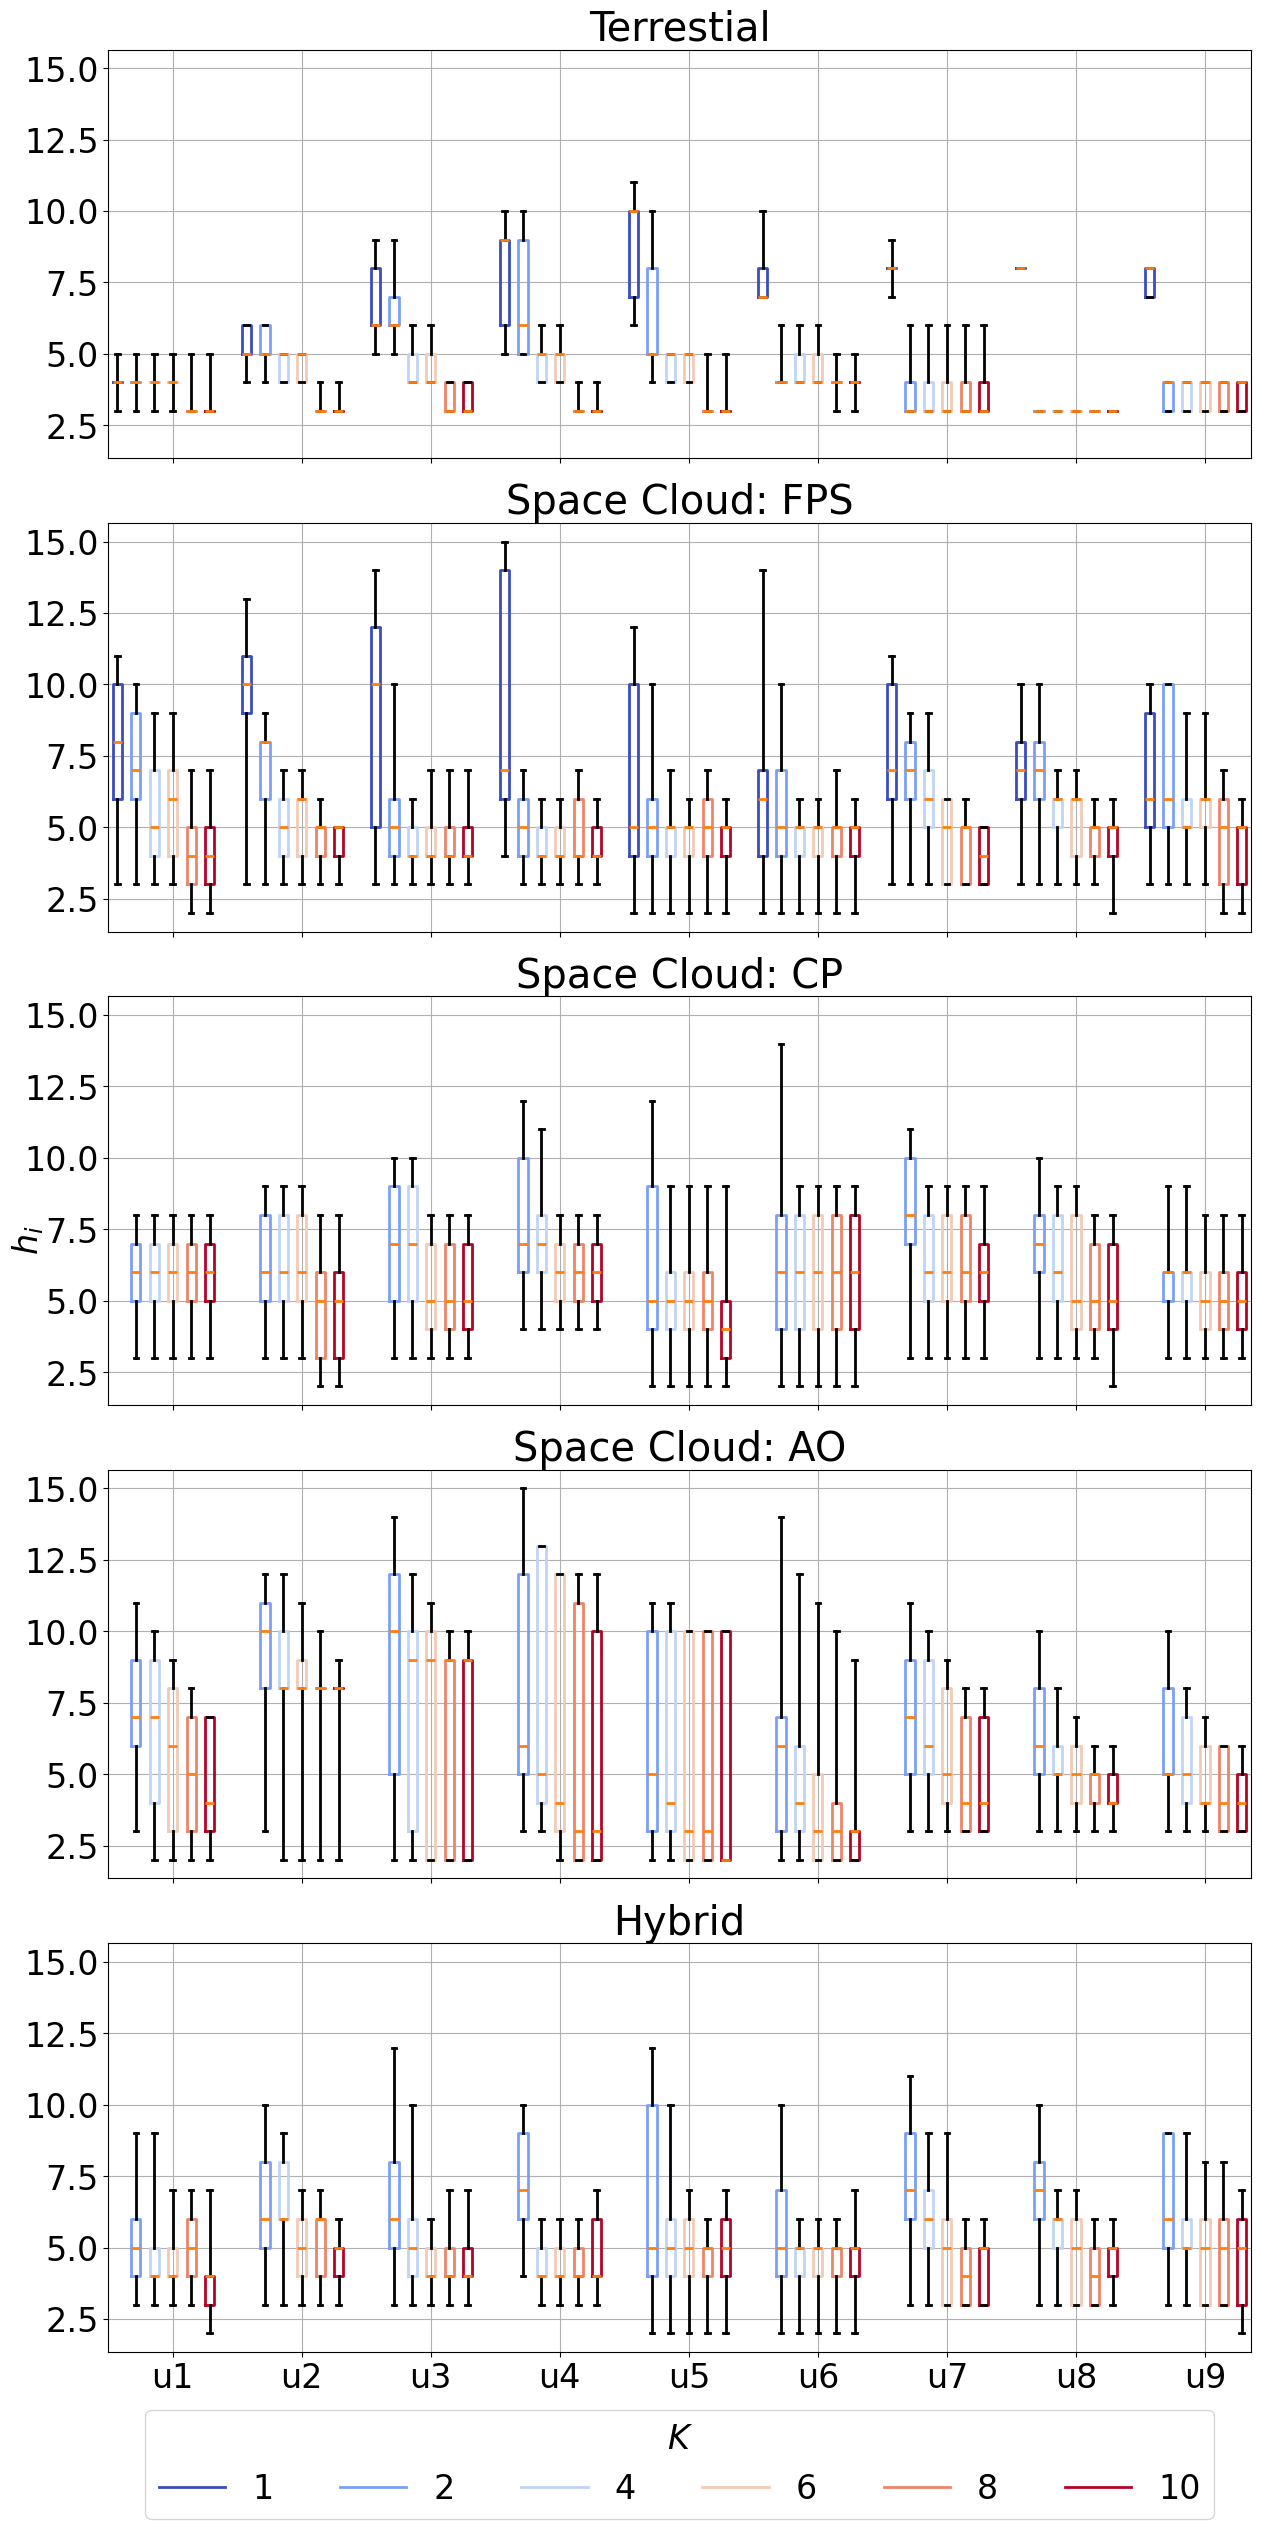

In [11]:
# print(data_dict.keys())

lwidth = 2
d_keys = data_dict.keys()
shade_init = 0.0
shade_end = 1.0

t_keys = [k for k in d_keys if 'Terrestrial' in k]
t_keys.sort(reverse=False)

n_grps = 1
# s_keys = [k for k in d_keys if 'Terrestrial' not in k and 'Farthest' not in k and 'Hybrid' not in k]
# if len(s_keys) > 0:
#     s_keys.sort(reverse=False)
#     s_keys.insert(0, s_keys.pop())
#     s_keys = [s_keys[0]] + s_keys[3:] + s_keys[1:3]
#     n_grps += 1


# f_keys = [k for k in d_keys if 'Farthest'  in k]
# if len(f_keys) > 0:
#     f_keys.sort(reverse=False)
#     n_grps += 1

# h_keys = [k for k in d_keys if 'Hybrid' in k]
# if len(h_keys) > 0:
#     h_keys.sort(reverse=False)
#     h_keys = [''] + h_keys + ['']
#     n_grps += 1


c_keys = [k for k in d_keys if 'Cross' in k]
if len(c_keys) > 0:
    c_keys.sort(reverse=False)
    c_keys = [''] + c_keys
    n_grps += 1
a_keys = [k for k in d_keys if 'Along' in k]
if len(a_keys) > 0:
    a_keys.sort(reverse=False)
    a_keys = [''] + a_keys
    n_grps += 1


f_keys = [k for k in d_keys if 'Farthest'  in k]
if len(f_keys) > 0:
    f_keys.sort(reverse=False)
    if len(t_keys) > len(f_keys):
        f_keys = f_keys + ['']*(len(t_keys)-len(f_keys))
    cmap3 = cm.coolwarm(np.linspace(shade_init, shade_end, len(f_keys)))
    n_grps += 1

h_keys = [k for k in d_keys if 'Hybrid' in k]
if len(h_keys) > 0:
    h_keys.sort(reverse=False)
    h_keys = [''] +h_keys
    n_grps += 1

print(f_keys)

def plot_hops(group_keys, ax, title='', user=None):
    cmap = cm.coolwarm(np.linspace(shade_init, shade_end, len(group_keys)))
    group_len = len(group_keys)
    l_handlers=[]
    for i_col, d_key in enumerate(group_keys):
        if d_key == "":
            continue
        
        data_df = data_dict[d_key]
        distances, latency = data_df['distances'], data_df['latency']
        # print(data_df)
        data = data_df['data']

        paths = [[len(p) for p in u_paths] for u_paths in data_df['paths']]
        mean_rtt = np.mean(data_df['latency'])
        props = dict(color=cmap[i_col], linewidth=lwidth)
        lprops = dict(linewidth=lwidth)
        ue_len = len(data_df)
        ax.set_title(title)
        # print(paths)
        ax.boxplot(paths, showfliers=False, positions=[(group_len+1)*i+i_col+1 for i in range(ue_len)],
                  boxprops=props, whis=(0,99), medianprops=lprops, whiskerprops=lprops, capprops=lprops)
        # ax.boxplot(paths, showfliers=False, positions=[(group_len+1)*i+i_col+1 for i in range(ue_len)])
        # ax.boxplot(data, showfliers=False, positions=[(group_len+1)*i+i_col+1 for i in range(ue_len)], 
        #            boxprops=props, meanline=True, medianprops=lprops,
        #            whis=(0,95), whiskerprops=lprops, capprops=lprops)
    ax.set_xticks([(group_len+1)*i + int(group_len/2)+1 for i in range(ue_len)],
              labels=[f"u{int(u[2:])-198}" for u in data_df['users']])
    ax.grid()
        # x_bar = np.array(list(range(minutes)))*(ngroups+1)+i
        # ax.bar(x_bar, all_hops, color=cmap[i])
    # ax.set_xticks(np.array(list(range(minutes)))*(ngroups+1)+2,
    #               labels=((np.array(list(range(minutes)))+1)*10).astype(str))
    # ax.set_title(title)
    # ax.legend(handles=l_handlers, loc='center right', bbox_to_anchor=(1.12, 0.5), title='Servers')
    # ax.grid()


fig, axs = plt.subplots(nrows=n_grps, sharey=True, sharex=True)
fig.set_figwidth(13)
fig.set_figheight(25)

# users = [i for i in range(9)]   # if i != 1:
# fig, axs = plt.subplots(nrows=1, ncols=n_grps, sharey=True)
# fig.set_figwidth(35)
# fig.set_figheight(6)

if n_grps ==1:
    axs = [axs]

# for i, u in enumerate(users):
cmap = cm.coolwarm(np.linspace(shade_init, shade_end, len(t_keys)))
t_handlers = plot_hops(t_keys, axs[0], title="Terrestial")
axi = 1

if len(f_keys) > 0:
    plot_hops(f_keys, axs[axi], title="Space Cloud: FPS")
    axi += 1
if len(c_keys) > 0:
    plot_hops(c_keys, axs[axi], title="Space Cloud: CP")
    axi += 1
if len(a_keys) > 0:
    plot_hops(a_keys, axs[axi], title="Space Cloud: AO")
    axi += 1


if len(h_keys) > 0:
    plot_hops(h_keys, axs[axi], title="Hybrid")


fig.text(0, 0.5, "$h_{i}$", va='center', rotation='vertical')
fig.tight_layout(pad=0.6, rect= (0.02, 0.03, 0.97, 1))



# fig.text(0.5, -0.01, "Minutes", va='center', rotation='horizontal')
# fig.legend(t_handlers, loc='center right', bbox_to_anchor=(0.5 -1.0), title='Servers')
# fig.tight_layout()
servers = [1, 2, 4, 6, 8, 10]
handlers = [(Line2D([0], [0], linestyle='-', marker=None, linewidth=lwidth, color=cmap[i], label=str(s),
            markerfacecolor=cmap[i], markersize=3)) for i, s in enumerate(servers)]

plt.legend(handles=handlers,ncols=6, loc='lower center', bbox_to_anchor=(0.5, -0.45), title='$K$')
plt.savefig('hops_boxes.pdf', bbox_inches='tight' )

In [12]:
def plot_hops_image(d_key, ax, title='', user=None, nc2=7):
    lwidth = 0
    # cmap = cm.coolwarm(np.linspace(shade_init, shade_end, len(group_keys)))
    # l_handlers=[]
    # for i, d_key in enumerate(group_keys):
    df1 = data_dict[d_key]
    
    times = df1.times.to_list()
    paths = df1.paths.to_list()

    # print(paths)
    
    minutes = 9
    min_step=600
    data = np.zeros((18, minutes))
    
    
    # if user:
    #     users = [user]
    #     user_times = times[user]
    #     user_paths = paths[user]
        
    # users = list(range(9))
    all_times = sum(times, [])
    all_paths = sum(paths, [])
        
    for m in range(minutes):
        
        uniq_paths = np.unique(sum([u for t, u in zip(all_times, all_paths) if t >= m*min_step and t < (m+1)*min_step], []))
        uniq_ids = [int(n.replace('st', '')) for n in uniq_paths if 'st' in n]

        for i in uniq_ids:
            data[int((i-1) / 11), m] += 1
    cmap = cm.YlGnBu(np.linspace(0, 1.0, 12))

    customap = colors.ListedColormap([cmap[i] for i in range(12)])
    bounds=[-0.5]+[i+0.5 for i in range(12)]
    norm = colors.BoundaryNorm(bounds, customap.N)
    im = ax.imshow(data, cmap=customap, norm=norm)

    map2=None
    if user:
    #     users = [user]
        cmap2 = cm.OrRd(np.linspace(0, 1.0, nc2))
        customap2 = colors.ListedColormap([cmap2[i] for i in range(nc2)])
        bounds2=[-0.5]+ [i+0.5 for i in range(nc2)]
        norm2 = colors.BoundaryNorm(bounds2, customap2.N)

        map2 = cm.ScalarMappable(norm=norm2, cmap=customap2)
        user_data = np.zeros((18, minutes))
        user_times = times[user]
        user_paths = paths[user]
        uniq_paths = []

        for m in range(minutes):
                
            uniq_paths2 = np.unique(sum([u for t, u in zip(user_times, user_paths) if t >= m*min_step and (t < (m+1)*min_step if m+1!=9 else True) ], []))

            if len(uniq_paths2) !=0:
                uniq_paths = uniq_paths2
            
            
            uniq_ids = [int(n.replace('st', '')) for n in uniq_paths if 'st' in n]

            print(uniq_ids, m)
            for i in uniq_ids:
                user_data[int((i-1) / 11), m] += 1

        # Add a rectangle per pixel with user data
        print('max ', np.max(user_data))
        rows, cols = user_data.shape
        s = 0.7
        for i in range(rows):
            for j in range(cols):
                # Center of pixel (j, i) is at data‐coords j+0.5, i+0.5
                cx, cy = j , i 
                # lower‐left corner of square
                llx = cx - s/2
                lly = cy - s/2
        
                # Optionally, color based on pixel value, e.g. white for dark pixels
                if user_data[i, j] != 0:
                    color = cmap2[int(user_data[i, j])]
            
                    square = patches.Rectangle(
                        (llx, lly),     # lower-left corner
                        s, s,           # width, height
                        linewidth=1,
                        edgecolor=None,
                        facecolor=color,
                        alpha=1.0
                    )
                    ax.add_patch(square)
    
    title = ''
    # servers = re.search(":(\\d\\d)", d_key).group(1)
    
    # s_servers = int(re.search("SS:(\\d+)", k).group(1))
    
    if 'Terrestrial' in d_key:
        servers = int(re.search("GS:(\\d+)", d_key).group(1))
        title = f'Terrestrial\n $K={servers}$'
    if 'Space' in d_key and 'Farthest' in d_key:
        servers = int(re.search("SS:(\\d+)", d_key).group(1))
        title = f'Space: FPS\n $K={servers}$'
    if 'Space' in d_key and 'Along' in d_key:
        servers = int(re.search("SS:(\\d+)", d_key).group(1))
        title = f'Space: AO\n $K={servers}$'
    if 'Hybrid' in d_key:
        s_servers = int(re.search("SS:(\\d+)", d_key).group(1))
        g_servers = int(re.search("GS:(\\d+)", d_key).group(1))
        title = f'Hybrid\n $K={s_servers+g_servers}$'

    
    ax.set_title(title)
    ax.set_xticks(list(range(0, data.shape[1])), labels=[str((c+1)*10) for c in range(0 ,data.shape[1])],
                  rotation=0, ha="center", rotation_mode="anchor")
    ax.set_yticks(range(data.shape[0]), labels=[str(c+1) for c in range(data.shape[0])])

    # Turn spines off and create white grid.
    ax.spines[:].set_visible(False)

    ax.set_xticks(np.arange(data.shape[1]+1)-.5, minor=True)
    ax.set_yticks(np.arange(data.shape[0]+1)-.5, minor=True)
    ax.set_xlabel('Minutes')
    ax.set_ylabel('Orbital Planes')
    # ax.grid(which="minor", color="w", linestyle='-', linewidth=3)
    ax.tick_params(which="minor", bottom=False, left=False)

    return im, map2

Terrestrial, GS:01
[136, 147, 157, 158, 159, 160] 0
[135, 146, 157, 158, 159] 1
[134, 135, 146, 157, 158] 2
[133, 134, 135, 143, 144, 145, 146, 154, 155, 156, 157, 164, 165] 3
[133, 134, 143, 144, 145, 153, 154, 156, 163, 166, 174, 175, 176, 18, 19, 29, 30, 40, 41, 51, 52, 62, 63, 7, 72, 73, 74, 8] 4
[16, 18, 27, 29, 38, 40, 49, 5, 51, 6, 60, 62, 7, 71, 72, 73] 5
[15, 16, 26, 27, 37, 38, 4, 48, 49, 5, 59, 6, 60, 70, 71] 6
[15, 26, 37, 4, 48, 5, 59, 70] 7
[15, 26, 37, 4, 48, 5, 59, 70] 8
max  5.0
[159, 160] 0
[158, 159, 160] 1
[157, 158, 159, 160] 2
[156, 157, 158, 159, 160] 3
[105, 116, 127, 138, 149, 156, 157, 158, 159, 160, 166, 167, 168, 72, 83, 94] 4
[104, 105, 115, 116, 126, 127, 137, 138, 148, 149, 159, 160, 71, 72, 82, 83, 93, 94] 5
[103, 104, 114, 115, 125, 126, 136, 137, 147, 148, 158, 159, 160, 70, 71, 81, 82, 92, 93] 6
[102, 103, 113, 114, 124, 125, 135, 136, 146, 147, 157, 158, 159, 160, 161, 162, 173, 70, 80, 81, 91, 92] 7
[160, 161, 162, 172, 173] 8
max  6.0
[159, 160] 0


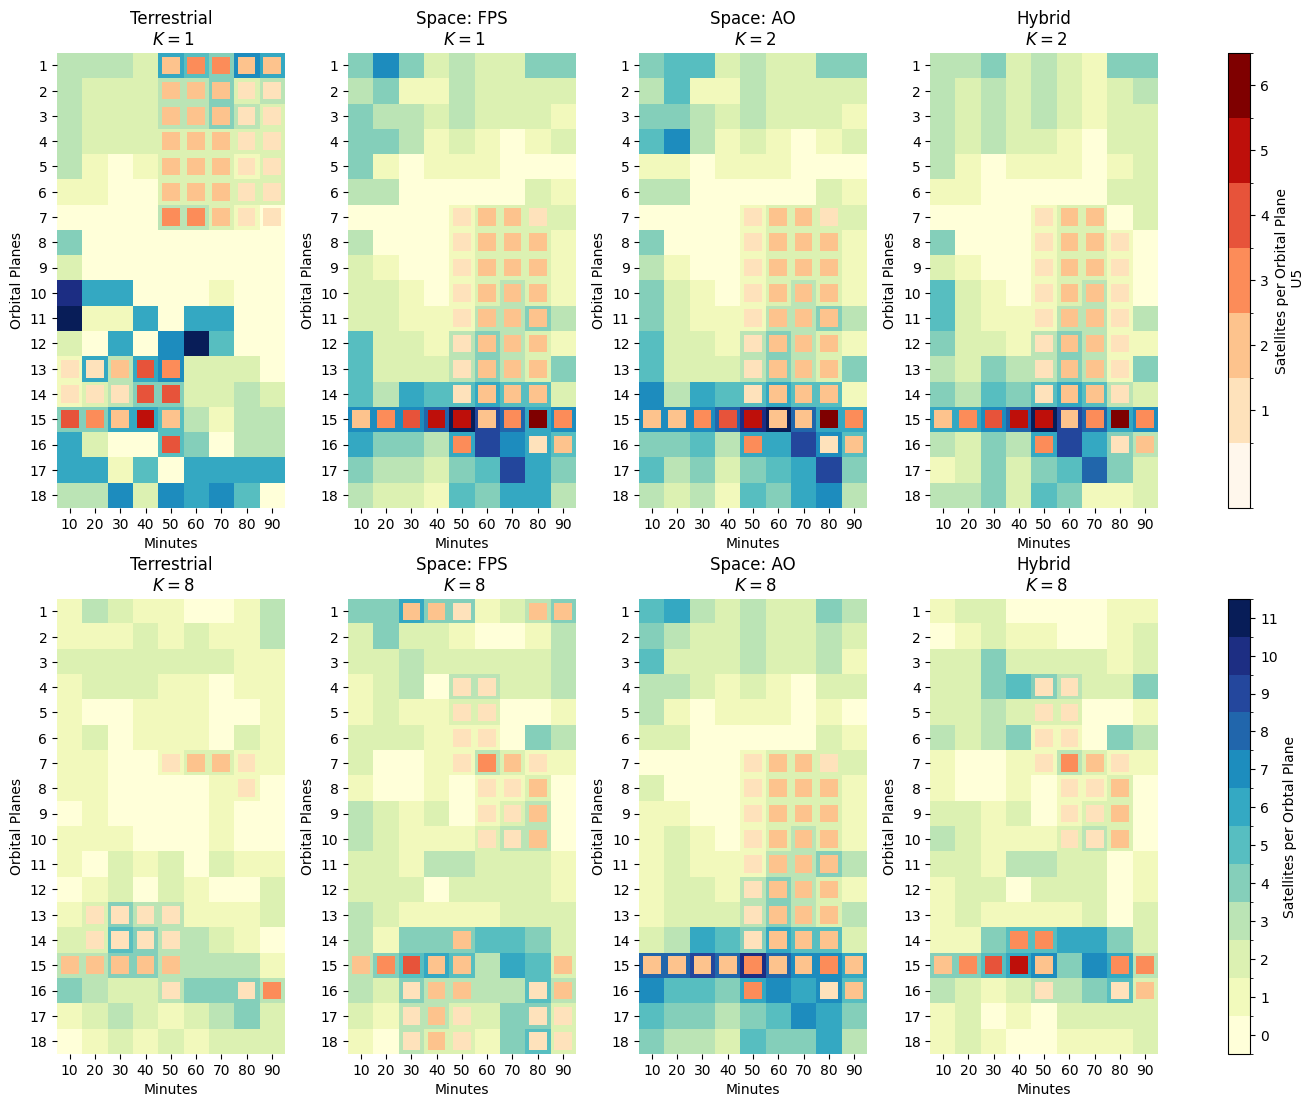

In [13]:

fsize = 10
matplotlib.rcParams.update({'font.size': fsize})
d_keys = data_dict.keys()
shade_init = 0.0
shade_end = 1.0


t_keys = [k for k in d_keys if 'Terrestrial' in k]
t_keys.sort(reverse=False)

# s_keys = [k for k in d_keys if 'Terrestrial' not in k and 'Farthest' not in k and 'Hybrid' not in k]
# s_keys.sort(reverse=False)
# s_keys.insert(0, s_keys.pop())
# s_keys = [s_keys[0]] + s_keys[3:] + s_keys[1:3]

f_keys = [k for k in d_keys if 'Farthest'  in k]
f_keys.sort(reverse=False)

a_keys = [k for k in d_keys if 'Along' in k]
if len(a_keys) > 0:
    a_keys.sort(reverse=False)
    a_keys = [''] + a_keys

h_keys = [k for k in d_keys if 'Hybrid' in k]
if len(h_keys) > 0:
    h_keys.sort(reverse=False)
    h_keys = [''] + h_keys
    

users = [i for i in range(2)]   # if i != 1:
    #     continue)]

# nrows=len(users)
nrows = 2
fig, axs = plt.subplots(nrows=nrows, ncols=4)
fig.set_figwidth(18)
fig.set_figheight(13)

# for i, u in enumerate(users):
user=4
im = None
# for i in range(0, 3):
print(t_keys[0])
im, map2 = plot_hops_image(t_keys[0], axs[0][0], '', user=user)
im, map2 = plot_hops_image(f_keys[0], axs[0][1], '', user=user)
im, map2 = plot_hops_image(a_keys[1], axs[0][2], '', user=user)
im, map2 = plot_hops_image(h_keys[1], axs[0][3], '', user=user)

# for i in range(6):
im, map2 = plot_hops_image(t_keys[4], axs[1][0], '', user=user)
im, map2 = plot_hops_image(f_keys[4], axs[1][1], '', user=user)
im, map2 = plot_hops_image(a_keys[4], axs[1][2], '', user=user)
im, map2 = plot_hops_image(h_keys[4], axs[1][3], '', user=user)


# cbar = fig.figure.colorbar(im)
# cbar.ax.set_ylabel("Satellites", va="bottom")
cbar = plt.colorbar(map2, orientation='vertical', ax=axs[0], pad=0.05, ticks=[i+1 for i in range(6)], label=f'Satellites per Orbital Plane\n U{user+1}')
cbar = plt.colorbar(im, orientation='vertical', ax=axs[1], pad=0.05, ticks=[i for i in range(12)], label='Satellites per Orbtal Plane' )

# cbar.ax.set_xticklabels([str(i) for i in range(12)])  # horizontal colorbar
plt.savefig('network_usage.pdf',  bbox_inches='tight')
# plt.subplots_adjust()
# plt.tight_layout()

# fig.tight_layout()

Terrestrial, GS:01
[136, 147, 157, 158, 159, 160] 0
[135, 146, 157, 158, 159] 1
[134, 135, 146, 157, 158] 2
[133, 134, 135, 143, 144, 145, 146, 154, 155, 156, 157, 164, 165] 3
[133, 134, 143, 144, 145, 153, 154, 156, 163, 166, 174, 175, 176, 18, 19, 29, 30, 40, 41, 51, 52, 62, 63, 7, 72, 73, 74, 8] 4
[16, 18, 27, 29, 38, 40, 49, 5, 51, 6, 60, 62, 7, 71, 72, 73] 5
[15, 16, 26, 27, 37, 38, 4, 48, 49, 5, 59, 6, 60, 70, 71] 6
[15, 26, 37, 4, 48, 5, 59, 70] 7
[15, 26, 37, 4, 48, 5, 59, 70] 8
max  5.0


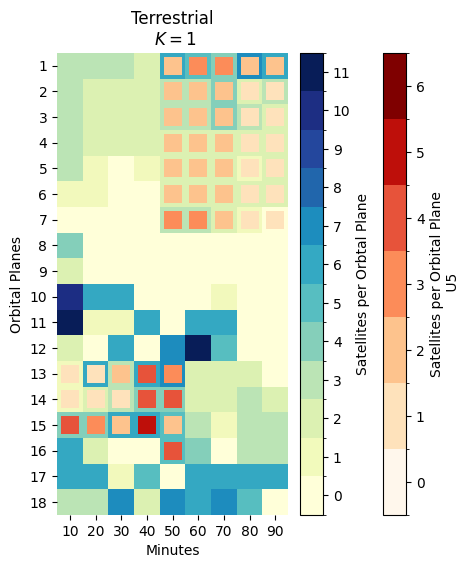

In [14]:
# nrows=len(users)
nrows = 1
fig, axs = plt.subplots(nrows=nrows, ncols=1)
fig.set_figwidth(9)
fig.set_figheight(6)

# for i, u in enumerate(users):
user=4
im = None
# for i in range(0, 3):
print(t_keys[0])
im, map2 = plot_hops_image(t_keys[0], axs, '', user=user, nc2=7)
cbar = plt.colorbar(map2, orientation='vertical', ax=axs, pad=-0.01, ticks=[i for i in range(7)], label=f'Satellites per Orbital Plane\n U{user+1}')
cbar = plt.colorbar(im, orientation='vertical', ax=axs, pad=0.02, ticks=[i for i in range(12)], label='Satellites per Orbtal Plane' )

# cbar.ax.set_xticklabels([str(i) for i in range(12)])  # horizontal colorbar
plt.savefig('network_usage_1t.pdf',  bbox_inches='tight')
# plt.subplots_adjust()
# plt.tight_layout()

# fig.tight_layout()

Terrestrial, GS:01
[159, 160] 0
[137, 148, 158, 159] 1
[136, 147, 157, 158] 2
[135, 146, 156, 157] 3
[134, 145, 155, 156, 166, 72] 4
[71, 72] 5
[70, 71] 6
[173, 70, 80] 7
[172, 173, 174] 8
max  3.0


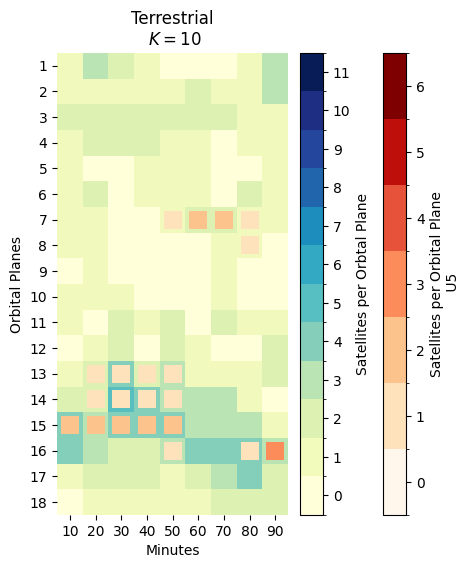

In [15]:
# nrows=len(users)
nrows = 1
fig, axs = plt.subplots(nrows=nrows, ncols=1)
fig.set_figwidth(9)
fig.set_figheight(6)
user=4
im = None
print(t_keys[0])
im, map2 = plot_hops_image(t_keys[5], axs, '', user=user, nc2=7)
cbar = plt.colorbar(map2, orientation='vertical', ax=axs, pad=-0.01, ticks=[i for i in range(7)], label=f'Satellites per Orbital Plane\n U{user+1}')
cbar = plt.colorbar(im, orientation='vertical', ax=axs, pad=0.02, ticks=[i for i in range(12)], label='Satellites per Orbtal Plane' )

# cbar.ax.set_xticklabels([str(i) for i in range(12)])  # horizontal colorbar
plt.savefig('network_usage_10t.pdf',  bbox_inches='tight')

Space: Farthest Choice, SS:01
[159, 160] 0
[158, 159, 160] 1
[157, 158, 159, 160] 2
[156, 157, 158, 159, 160] 3
[105, 116, 127, 138, 149, 156, 157, 158, 159, 160, 166, 167, 168, 72, 83, 94] 4
[104, 105, 115, 116, 126, 127, 137, 138, 148, 149, 159, 160, 71, 72, 82, 83, 93, 94] 5
[103, 104, 114, 115, 125, 126, 136, 137, 147, 148, 158, 159, 160, 70, 71, 81, 82, 92, 93] 6
[102, 103, 113, 114, 124, 125, 135, 136, 146, 147, 157, 158, 159, 160, 161, 162, 173, 70, 80, 81, 91, 92] 7
[160, 161, 162, 172, 173] 8
max  6.0


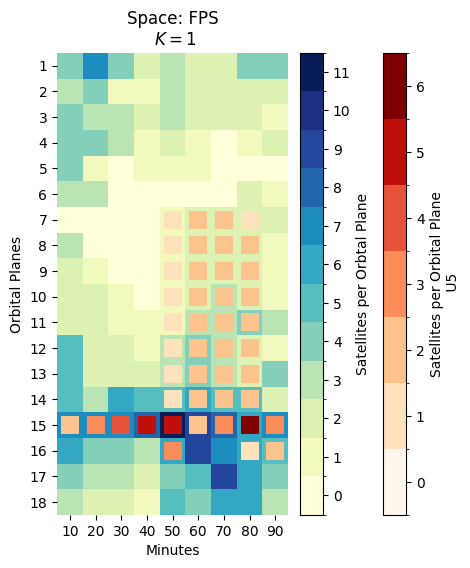

In [16]:
# nrows=len(users)
nrows = 1
fig, axs = plt.subplots(nrows=nrows, ncols=1)
fig.set_figwidth(9)
fig.set_figheight(6)
user=4
im = None
print(f_keys[0])
im, map2 = plot_hops_image(f_keys[0], axs, '', user=user, nc2=7)
cbar = plt.colorbar(map2, orientation='vertical', ax=axs, pad=-0.01, ticks=[i for i in range(7)], label=f'Satellites per Orbital Plane\n U{user+1}')
cbar = plt.colorbar(im, orientation='vertical', ax=axs, pad=0.02, ticks=[i for i in range(12)], label='Satellites per Orbtal Plane' )

# cbar.ax.set_xticklabels([str(i) for i in range(12)])  # horizontal colorbar
plt.savefig('network_usage_1f.pdf',  bbox_inches='tight')

Space: Farthest Choice, SS:01
[159, 160] 0
[158, 159, 160, 169, 180] 1
[157, 158, 168, 169, 179, 180] 2
[123, 134, 145, 156, 157, 168, 179, 180] 3
[123, 134, 144, 145, 154, 155, 156, 166, 39, 50, 61, 72] 4
[103, 39, 50, 61, 70, 71, 72, 81, 92] 5
[103, 70, 71, 81, 92] 6
[10, 102, 103, 173, 184, 195, 70, 80, 81, 9, 91, 92] 7
[10, 160, 161, 172, 173, 184, 195, 9] 8
max  3.0


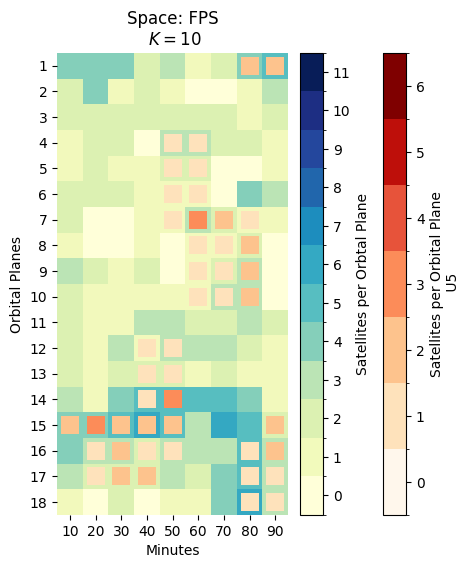

In [17]:
# nrows=len(users)
nrows = 1
fig, axs = plt.subplots(nrows=nrows, ncols=1)
fig.set_figwidth(9)
fig.set_figheight(6)
user=4
im = None
print(f_keys[0])
im, map2 = plot_hops_image(f_keys[5], axs, '', user=user, nc2=7)
cbar = plt.colorbar(map2, orientation='vertical', ax=axs, pad=-0.01, ticks=[i for i in range(7)], label=f'Satellites per Orbital Plane\n U{user+1}')
cbar = plt.colorbar(im, orientation='vertical', ax=axs, pad=0.02, ticks=[i for i in range(12)], label='Satellites per Orbtal Plane' )

# cbar.ax.set_xticklabels([str(i) for i in range(12)])  # horizontal colorbar
plt.savefig('network_usage_10f.pdf',  bbox_inches='tight')

In [71]:

keys = list(data_dict.keys())
print(keys)
d_key = keys[0]
df1 = data_dict[d_key]

df1

['Terrestrial, GS:10', 'Terrestrial, GS:03', 'Terrestrial, GS:13', 'Terrestrial, GS:05', 'Terrestrial, GS:01', 'Terrestrial, GS:07', 'Space: Farthest Choice, SS:10', 'Space: Farthest Choice, SS:01', 'Space: Farthest Choice, SS:07', 'Space: Farthest Choice, SS:13', 'Space: Farthest Choice, SS:03', 'Space: Farthest Choice, SS:05', 'Hybrid, SS:02, GS:01']


,gateway,users,distances,latency,hops,max,min,std,data,paths,times,ntasks
0,gg208,gn199,3374.130401,225.075169,3.475110,2171.970844,145.763874,149.424226,"[270.51830291748047, 226.07660293579102, 222.0...","[[gn199, st147, st136, gg208], [gn199, st147, ...","[13.764954092645224, 15.83331806253394, 16.267...",1587
1,gg208,gn200,5570.519938,193.929839,3.273626,2213.780403,116.188765,140.435094,"[161.8671417236328, 123.76809120178223, 122.80...","[[gn200, st24, gg215], [gn200, st24, gg215], [...","[4.465674161245358, 4.932482023778248, 5.15123...",1619
2,gg208,gn201,7781.953619,228.814965,3.583594,1827.480316,139.456749,127.181523,"[273.4692096710205, 222.557783126831, 226.8497...","[[gn201, st159, st148, gg215], [gn201, st159, ...","[1.5557433568718997, 2.026471115218897, 2.8614...",1597
3,gg208,gn202,9999.451388,194.836054,3.200734,1799.098253,146.191597,106.147150,"[189.1496181488037, 147.6578712463379, 149.377...","[[gn202, st45, gg214], [gn202, st45, gg214], [...","[1.7184998276593733, 5.022852689576996, 5.9053...",1634
4,gg208,gn203,12217.863297,193.068181,3.333131,2032.470942,122.166634,106.419818,"[158.2581996917724, 122.5118637084961, 124.372...","[[gn203, st160, gg214], [gn203, st160, gg214],...","[3.294210285246556, 3.773795855487181, 8.44176...",1651
5,gg208,gn204,14431.585468,271.680110,4.140403,1916.486263,129.640341,123.426223,"[289.5474433898926, 228.6617755889892, 236.698...","[[gn204, st88, st77, gg214], [gn204, st88, st7...","[1.8964089993056013, 9.717284296058532, 20.512...",1688
6,gg208,gn205,16630.491674,232.539541,3.671642,1495.949507,131.086111,107.956335,"[192.5485134124756, 152.8310775756836, 193.450...","[[gn205, st109, gg209], [gn205, st109, gg209],...","[6.544213198095377, 7.685311322260759, 29.1312...",1608
7,gg208,gn206,18750.545536,166.521578,3.012828,1281.641722,129.257441,74.820216,"[171.3118553161621, 135.25795936584473, 137.71...","[[gn206, st120, gg209], [gn206, st120, gg209],...","[7.5806885414109715, 11.02215451669634, 11.324...",1637
8,gg208,gn207,18774.126361,228.011968,3.686483,1979.206324,134.131670,130.456396,"[177.901029586792, 142.77219772338862, 144.196...","[[gn207, st173, gg209], [gn207, st173, gg209],...","[10.472472466067432, 16.254326181830237, 17.81...",1598


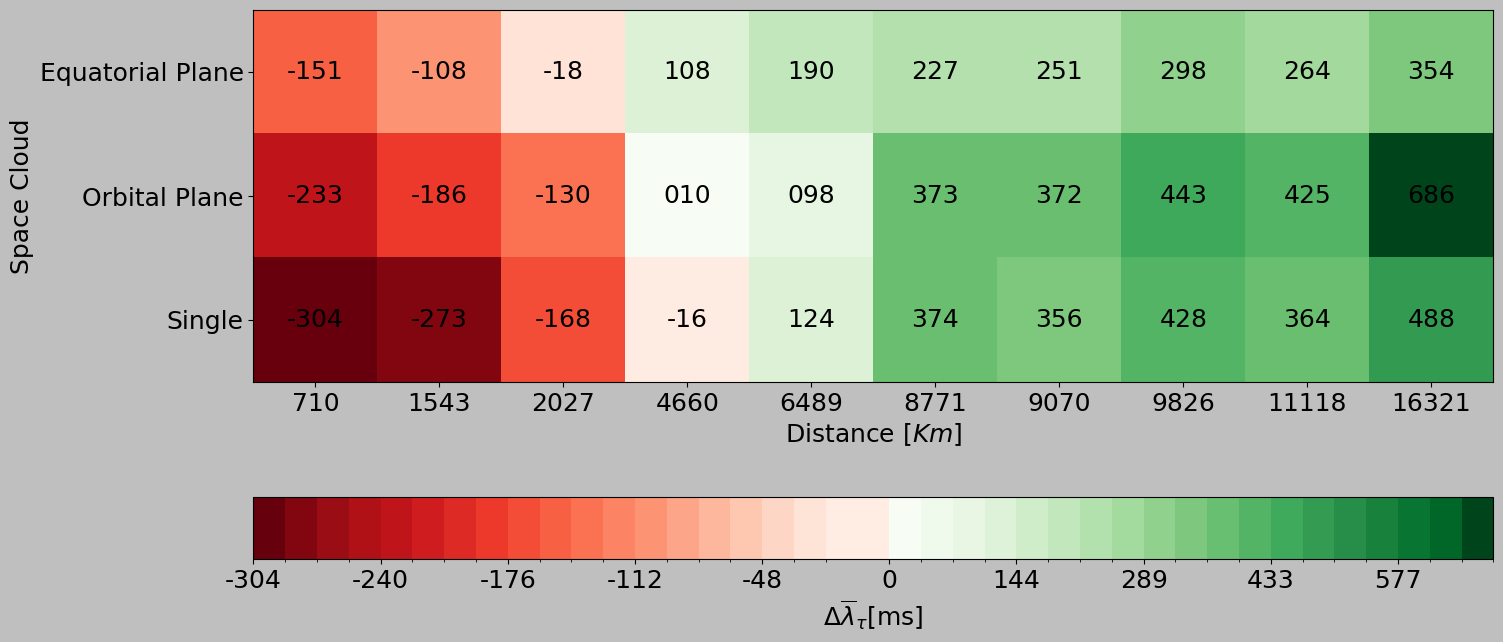

In [27]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib as mlp



n_colors= 20

cmapg = mlp.colormaps['Greens'].resampled(n_colors)
cmapr = mlp.colormaps['Reds'].resampled(n_colors)

# define the colormap
cmap = plt.cm.jet
cmaplist = [cmapr(i) for i in range(Terrestrialcmapr.N)][::-1] + [cmapg(i) for i in range(cmapg.N)]
cmap = cmap.from_list('Custom cmap', cmaplist, cmapg.N + cmapr.N)

bounds = np.array([np.linspace(np.min(X), 0.0, n_colors), np.linspace(0.0, np.max(X), n_colors)]).flatten()
norm = BoundaryNorm(bounds, cmap.N)
plt.rcParams['font.size'] = 18

# ax.plot(space_distances_1, space_net_1, label='Space Cloud: Single Distribution', marker='.', linestyle='dotted')
# ax.plot(space_distances_10, space_net_10, label='Space Cloud: Orbital Plane Distribution', marker='.',linestyle='dashed')
# ax.plot(space_distances_10_ec, space_net_10_ec, label='Space Cloud: Equatorial Plane Distribution', marker='.', linestyle='dashdot')
fig, ax = plt.subplots(figsize=(16,10))

im = ax.imshow(X,interpolation='none',norm=norm, cmap=cmap)
ax.set_xticks(np.arange(X.shape[1]), labels=['{0:3.0f}'.format(d) for d in gnd_distances])
ax.set_yticks(np.arange(X.shape[0]), labels=['Equatorial Plane', 'Orbital Plane', 'Single' ])
ax.set_ylabel('Space Cloud')
ax.set_xlabel('Distance [$Km$]')


for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        text = ax.text(j, i, '{:03.0f}'.format(X[i, j]),
                       ha="center", va="center", color="black")
plt.colorbar(im,location="bottom", format='%.0f', label="$\Delta \overline{\\lambda}_{\\tau}$[ms]")
plt.savefig('mean_latency_comparison.pdf', bbox_inches="tight", format='pdf')
plt.show()
